In [ ]:
# PCA on breast cancer dataset (do as an assignment)

In [ ]:
# PCA on digits dataset

In [ ]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

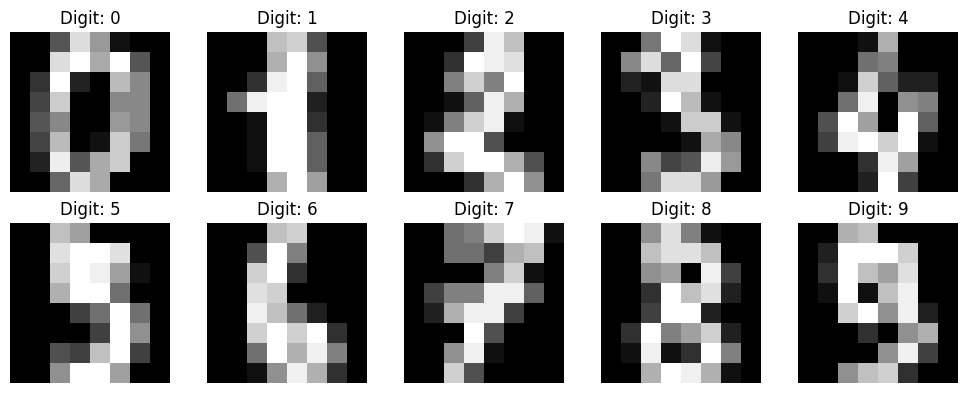

In [3]:
# load digits dataset
digits = load_digits()

# visualize the digits dataset
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Digit: {digits.target[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [21]:
# convert to dataframe
import pandas as pd
digits_df = pd.DataFrame(digits.data, columns=[f'pixel_{i}' for i in range(digits.data.shape[1])])
digits_df['target'] = digits.target

In [22]:
digits_df.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [24]:
# Feature Scaling using StandardScaler
features = digits_df.drop('target', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# split into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(scaled_features, digits_df['target'], test_size=0.2, random_state=42)


In [25]:
# Apply KNN on full data

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_full = knn.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report (Full Data):")
print(classification_report(y_test, y_pred_full))
print("Confusion Matrix (Full Data):")
print(confusion_matrix(y_test, y_pred_full))

# print accuracy score
from sklearn.metrics import accuracy_score
accuracy_full = accuracy_score(y_test, y_pred_full)
print(f"Accuracy (Full Data): {accuracy_full:.4f}")

Classification Report (Full Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      1.00      0.98        30
           9       0.95      0.90      0.92        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.97       360

Confusion Matrix (Full Data):
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  1 33  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0 

In [8]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [9]:
# 3D PCA Visualization using plotly
import plotly.express as px

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(scaled_features)
pca_df_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['target'] = digits_df['target']
fig = px.scatter_3d(pca_df_3d, x='PC1', y='PC2', z='PC3', color='target',
                    title='3D PCA of Digits Dataset')
fig.show()




In [10]:
# 2D PCA Visualization using plotly
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(scaled_features)
pca_df_2d = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df_2d['target'] = digits_df['target']
fig = px.scatter(pca_df_2d, x='PC1', y='PC2', color='target',
                    title='2D PCA of Digits Dataset')   
fig.show()

In [26]:
# apply KNN on PCA-reduced data

pca = PCA(n_components=20)  # choose number of components to retain
X_pca = pca.fit_transform(scaled_features)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, digits_df['target'], test_size=0.2, random_state=42)

# fit KNN on PCA-reduced data
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = knn_pca.predict(X_test_pca)
print("Classification Report (PCA-Reduced Data):")
print(classification_report(y_test_pca, y_pred_pca))
print("Confusion Matrix (PCA-Reduced Data):")
print(confusion_matrix(y_test_pca, y_pred_pca))
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)
print(f"Accuracy (PCA-Reduced Data): {accuracy_pca:.4f}")


Classification Report (PCA-Reduced Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.96      0.96      0.96        28
           2       0.94      0.97      0.96        33
           3       0.94      0.97      0.96        34
           4       1.00      1.00      1.00        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       0.97      0.94      0.96        34
           8       0.91      0.97      0.94        30
           9       0.95      0.88      0.91        40

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360

Confusion Matrix (PCA-Reduced Data):
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 27  0  0  0  0  0  0  1  0]
 [ 0  1 32  0  0  0  0  0  0  0]
 [ 0  0  1 33  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  

In [15]:
# Accuracy change by increasing number of PCA components
components_range = range(1, 65)  # from 1 to 64 components
accuracy_scores = []
for n_components in components_range:
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(scaled_features)
    X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, digits_df['target'], test_size=0.2, random_state=42)
    knn.fit(X_train_pca, y_train_pca)
    y_pred_pca = knn.predict(X_test_pca)
    accuracy_scores.append(accuracy_score(y_test_pca, y_pred_pca))
    

In [16]:
# print the accuracy scores for different number of components
for n_components, acc in zip(components_range, accuracy_scores):
    print(f"Number of PCA Components: {n_components}, Accuracy: {acc:.4f}")
    

Number of PCA Components: 1, Accuracy: 0.3444
Number of PCA Components: 2, Accuracy: 0.5444
Number of PCA Components: 3, Accuracy: 0.6806
Number of PCA Components: 4, Accuracy: 0.8583
Number of PCA Components: 5, Accuracy: 0.8917
Number of PCA Components: 6, Accuracy: 0.8944
Number of PCA Components: 7, Accuracy: 0.9306
Number of PCA Components: 8, Accuracy: 0.9361
Number of PCA Components: 9, Accuracy: 0.9417
Number of PCA Components: 10, Accuracy: 0.9472
Number of PCA Components: 11, Accuracy: 0.9472
Number of PCA Components: 12, Accuracy: 0.9417
Number of PCA Components: 13, Accuracy: 0.9417
Number of PCA Components: 14, Accuracy: 0.9639
Number of PCA Components: 15, Accuracy: 0.9639
Number of PCA Components: 16, Accuracy: 0.9667
Number of PCA Components: 17, Accuracy: 0.9667
Number of PCA Components: 18, Accuracy: 0.9667
Number of PCA Components: 19, Accuracy: 0.9667
Number of PCA Components: 20, Accuracy: 0.9639
Number of PCA Components: 21, Accuracy: 0.9639
Number of PCA Componen

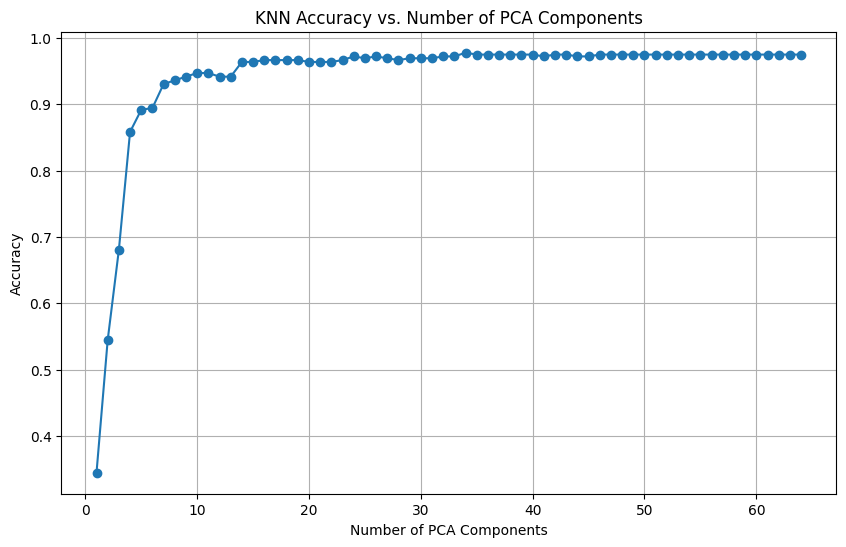

In [17]:
# Visualize the accuracy scores as a function of the number of PCA components
plt.figure(figsize=(10, 6))
plt.plot(components_range, accuracy_scores, marker='o')
plt.title('KNN Accuracy vs. Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

In [ ]:
# Summary
# Without PCA, accuracy was 97.5 but with 64 features
# With PCA (20 components), accuracy was 96.4 but with only 20 features
# with very little drop in accuracy, we reduced the number of features by more than 3x, 
#    which can lead to faster training and inference times in real-world applications.

In [30]:
# Check the improvement in inference time with PCA-reduced data
import time
# Measure inference time on full data
start_time_full = time.time()
y_pred_full = knn.predict(X_test)
end_time_full = time.time()

inference_time_full = end_time_full - start_time_full
print(f"Inference Time (Full Data): {inference_time_full:.6f} seconds")

# Measure inference time on PCA-reduced data
start_time_pca = time.time()
y_pred_pca = knn_pca.predict(X_test_pca)
end_time_pca = time.time()
inference_time_pca = end_time_pca - start_time_pca
print(f"Inference Time (PCA-Reduced Data): {inference_time_pca:.6f} seconds")

# the % reduction in inference time
time_reduction = ((inference_time_full - inference_time_pca) / inference_time_full) * 100
print(f"Reduction in Inference Time: {time_reduction:.2f}%")


Inference Time (Full Data): 0.023428 seconds
Inference Time (PCA-Reduced Data): 0.013307 seconds
Reduction in Inference Time: 43.20%
